# 1. Imports & Config

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


SALES_CSV_PATH = "/kaggle/input/competitions/datathon-2026-round-1/sales.csv"
OUTPUT_CSV_PATH = "submission.csv"

FUTURE_START = "2023-01-01"
FUTURE_END = "2024-07-01"

TAIL_EVAL_START = "2021-01-01"
TAIL_EVAL_END = "2022-12-31"

RANDOM_STATE = 42

# 2. Load & Inpsect Data

## Load Data

Đọc file dữ liệu gốc, parse cột `Date` về dạng datetime, sau đó sắp xếp theo thời gian để đảm bảo các bước rolling và split theo thời gian hoạt động đúng.

In [20]:
def load_data(path):
    """
    Load sales data from a CSV file and sort it by Date.

    Parameters
    ----------
    path : str
        Path to the sales CSV file. The file must contain a Date column.

    Returns
    -------
    pd.DataFrame
        DataFrame sorted by Date with Date parsed as datetime.
    """
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    return df

df = load_data(SALES_CSV_PATH)

print(df.shape)
display(df.head(5))
display(df.describe())

(3833, 3)


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


,Date,Revenue,COGS
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06


## Inspect Data

Tổng hợp dữ liệu theo tháng để trực quan hóa xu hướng Revenue/COGS và phát hiện các đoạn dữ liệu có thay đổi bất thường.

In [21]:
def make_monthly_inspect(df):
    """
    Aggregate daily sales data into monthly inspection features.

    The function creates monthly revenue and COGS summaries, rolling averages,
    and month-over-month change rates for visual inspection.

    Parameters
    ----------
    df : pd.DataFrame
        Input daily sales data with Date, Revenue, and COGS columns.

    Returns
    -------
    pd.DataFrame
        Monthly aggregated DataFrame with revenue, COGS, rolling statistics,
        and month-over-month change features.
    """
    monthly = (
        df.set_index("Date")
        .resample("MS")
        .agg(
            revenue_sum=("Revenue", "sum"),
            revenue_mean=("Revenue", "mean"),
            cogs_sum=("COGS", "sum"),
            cogs_mean=("COGS", "mean"),
            days=("Revenue", "count"),
        )
        .reset_index()
    )

    monthly["revenue_mean_roll3"] = monthly["revenue_mean"].rolling(3, min_periods=1).mean()
    monthly["revenue_sum_roll3"] = monthly["revenue_sum"].rolling(3, min_periods=1).mean()
    monthly["cogs_mean_roll3"] = monthly["cogs_mean"].rolling(3, min_periods=1).mean()

    monthly["revenue_mean_mom"] = monthly["revenue_mean"].pct_change()
    monthly["revenue_sum_mom"] = monthly["revenue_sum"].pct_change()

    return monthly


monthly_inspect = make_monthly_inspect(df)

print("Data range:", df["Date"].min(), "->", df["Date"].max())
print("Rows:", len(df))
print("Missing values:")
display(df[["Date", "Revenue", "COGS"]].isna().sum())

Data range: 2012-07-04 00:00:00 -> 2022-12-31 00:00:00
Rows: 3833
Missing values:


Date       0
Revenue    0
COGS       0
dtype: int64

Vẽ xu hướng Revenue trung bình theo tháng để quan sát tổng thể mức doanh thu và các thay đổi regime trong toàn bộ lịch sử.

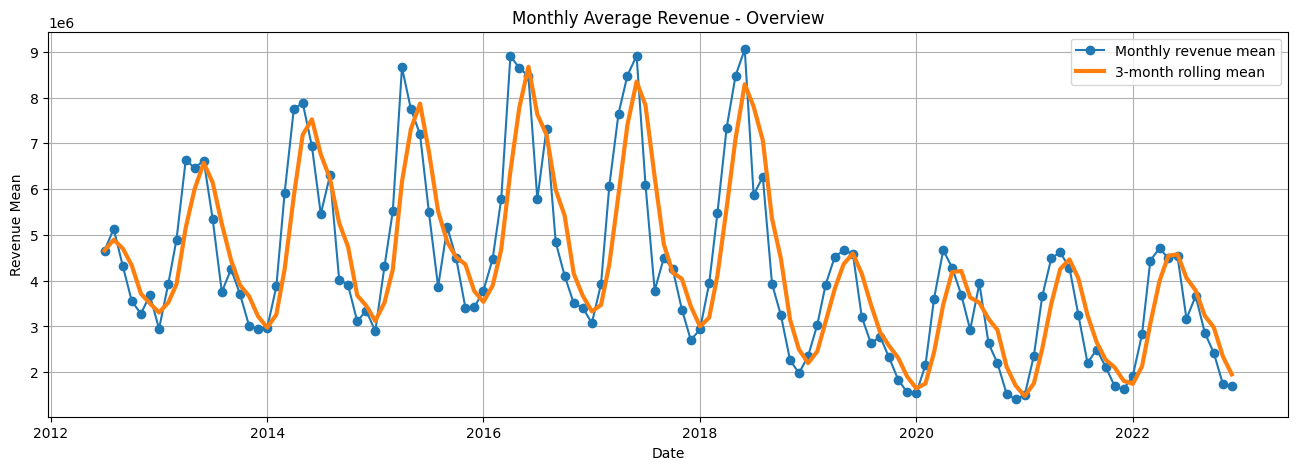

In [22]:
def plot_monthly_revenue_overview(monthly):
    """
    Plot monthly average revenue and its 3-month rolling mean.

    This chart is used to visually inspect the overall revenue level and
    identify potential structural changes over time.

    Parameters
    ----------
    monthly : pd.DataFrame
        Monthly inspection DataFrame returned by make_monthly_inspect.

    Returns
    -------
    None
        Displays a matplotlib line chart.
    """
    plt.figure(figsize=(16, 5))
    plt.plot(
        monthly["Date"],
        monthly["revenue_mean"],
        marker="o",
        label="Monthly revenue mean"
    )
    plt.plot(
        monthly["Date"],
        monthly["revenue_mean_roll3"],
        linewidth=3,
        label="3-month rolling mean"
    )

    plt.title("Monthly Average Revenue - Overview")
    plt.xlabel("Date")
    plt.ylabel("Revenue Mean")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_monthly_revenue_overview(monthly_inspect)

Vẽ tổng Revenue theo tháng để kiểm tra liệu biến động đến từ mức doanh thu trung bình hay từ số ngày/dòng dữ liệu trong từng tháng.

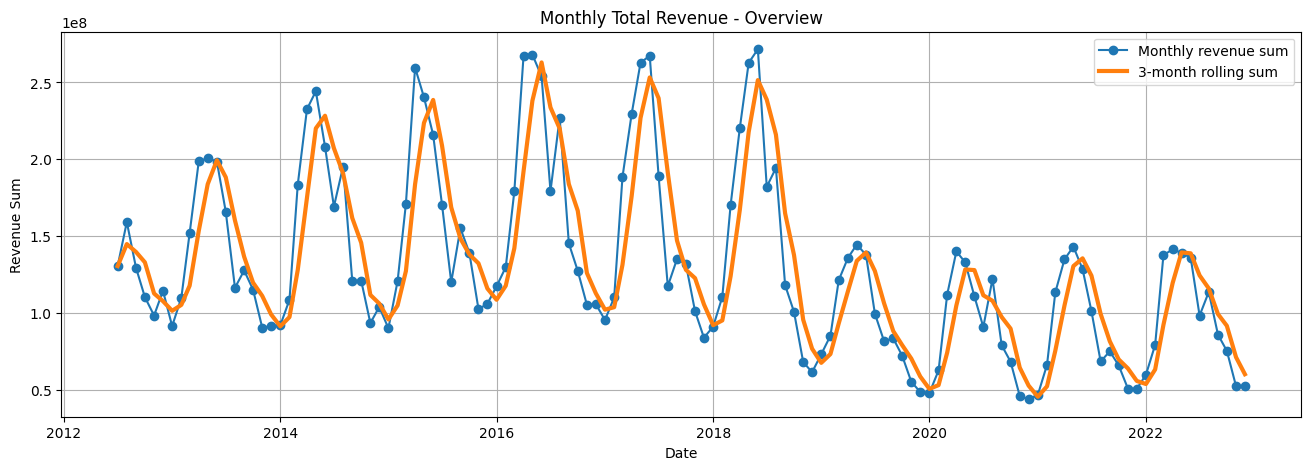

In [23]:
def plot_monthly_revenue_sum_overview(monthly):
    """
    Plot monthly total revenue and its 3-month rolling sum.

    This chart helps compare total monthly revenue over time and distinguish
    level changes from possible changes in monthly data volume.

    Parameters
    ----------
    monthly : pd.DataFrame
        Monthly inspection DataFrame returned by make_monthly_inspect.

    Returns
    -------
    None
        Displays a matplotlib line chart.
    """
    plt.figure(figsize=(16, 5))
    plt.plot(
        monthly["Date"],
        monthly["revenue_sum"],
        marker="o",
        label="Monthly revenue sum"
    )
    plt.plot(
        monthly["Date"],
        monthly["revenue_sum_roll3"],
        linewidth=3,
        label="3-month rolling sum"
    )

    plt.title("Monthly Total Revenue - Overview")
    plt.xlabel("Date")
    plt.ylabel("Revenue Sum")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_monthly_revenue_sum_overview(monthly_inspect)

Vẽ tỷ lệ thay đổi Revenue trung bình theo tháng để làm nổi bật các tháng có biến động mạnh, từ đó hỗ trợ phát hiện điểm gãy dữ liệu.

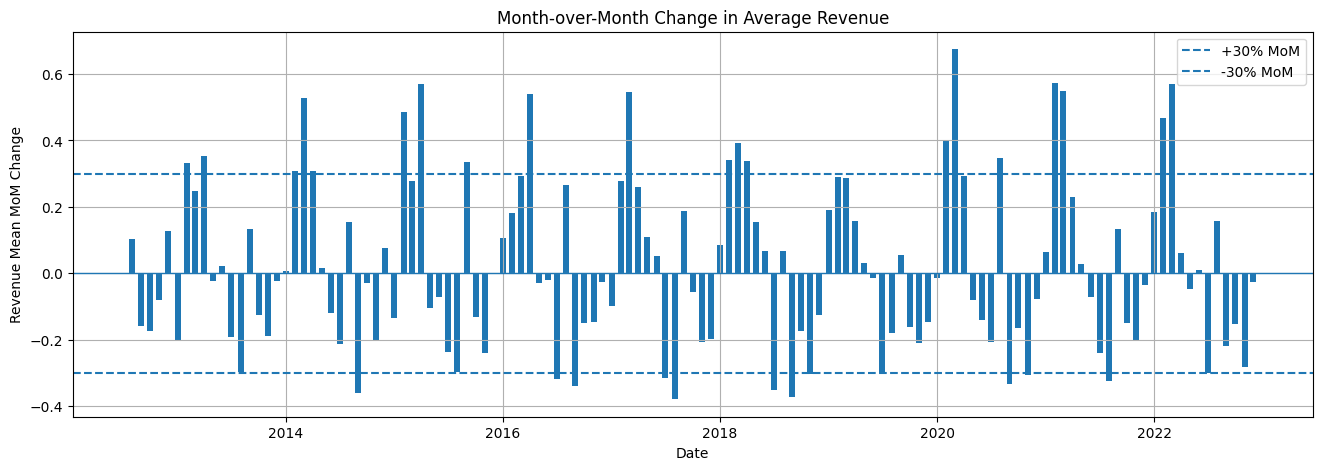

In [24]:
def plot_monthly_change_rate(monthly):
    """
    Plot month-over-month change rate of monthly average revenue.

    Large positive or negative bars indicate months where revenue level changed
    sharply compared with the previous month.

    Parameters
    ----------
    monthly : pd.DataFrame
        Monthly inspection DataFrame containing revenue_mean_mom.

    Returns
    -------
    None
        Displays a matplotlib bar chart.
    """
    plt.figure(figsize=(16, 5))
    plt.bar(monthly["Date"], monthly["revenue_mean_mom"], width=20)

    plt.axhline(0, linewidth=1)
    plt.axhline(0.30, linestyle="--", label="+30% MoM")
    plt.axhline(-0.30, linestyle="--", label="-30% MoM")

    plt.title("Month-over-Month Change in Average Revenue")
    plt.xlabel("Date")
    plt.ylabel("Revenue Mean MoM Change")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_monthly_change_rate(monthly_inspect)

Phóng to một giai đoạn nghi ngờ có thay đổi cấu trúc để quan sát kỹ hơn pattern trước, trong và sau đoạn đó.

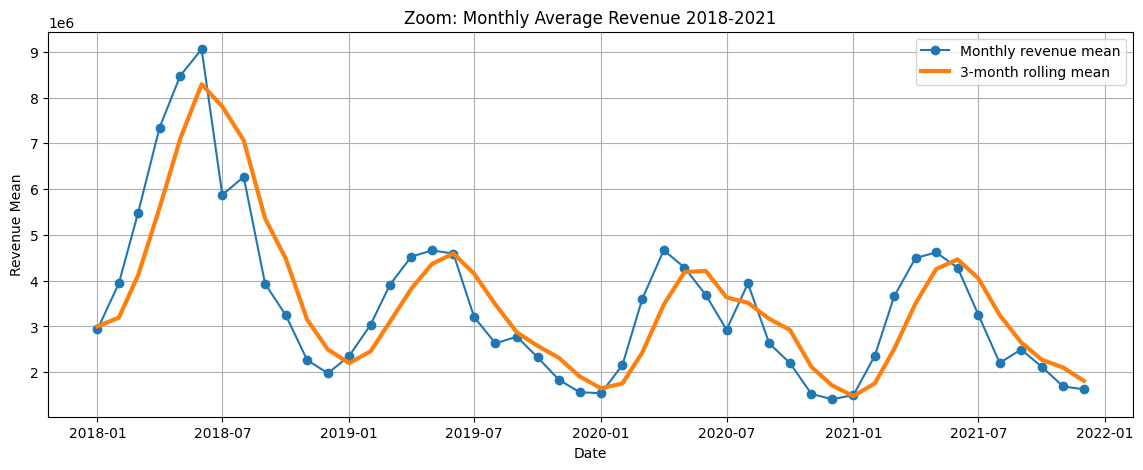

In [25]:
def plot_zoom_period(monthly, start="2018-01-01", end="2021-12-31"):
    """
    Plot monthly average revenue for a selected time window.

    This function is useful after the overview chart suggests a suspicious
    period that should be inspected more closely.

    Parameters
    ----------
    monthly : pd.DataFrame
        Monthly inspection DataFrame.
    start : str, default="2018-01-01"
        Start date of the zoom period.
    end : str, default="2021-12-31"
        End date of the zoom period.

    Returns
    -------
    None
        Displays a matplotlib line chart for the selected period.
    """
    period = monthly[
        (monthly["Date"] >= pd.Timestamp(start)) &
        (monthly["Date"] <= pd.Timestamp(end))
    ].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(
        period["Date"],
        period["revenue_mean"],
        marker="o",
        label="Monthly revenue mean"
    )
    plt.plot(
        period["Date"],
        period["revenue_mean_roll3"],
        linewidth=3,
        label="3-month rolling mean"
    )

    plt.title(f"Zoom: Monthly Average Revenue {start[:4]}-{end[:4]}")
    plt.xlabel("Date")
    plt.ylabel("Revenue Mean")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_zoom_period(
    monthly_inspect,
    start="2018-01-01",
    end="2021-12-31",
)

# 3. Feature Engineering

Tạo các biến đặc trưng từ lịch như tháng, ngày trong tuần, quý, cuối tuần, đầu/cuối tháng và các biến chu kỳ để model học được seasonal pattern.

In [26]:
def add_calendar_features(df):
    """
    Add calendar, cyclical, trend, and interaction features.

    These features represent day/week/month/quarter effects, cyclical seasonality,
    long-term trends, and post-cutoff trend changes.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with a Date column.

    Returns
    -------
    pd.DataFrame
        DataFrame with additional calendar and time-based features.
    """
    df = df.copy()

    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["Date"].dt.quarter
    df["days_in_month"] = df["Date"].dt.days_in_month

    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)
    df["is_quarter_start"] = df["Date"].dt.is_quarter_start.astype(int)
    df["is_quarter_end"] = df["Date"].dt.is_quarter_end.astype(int)
    df["is_year_start"] = df["Date"].dt.is_year_start.astype(int)
    df["is_year_end"] = df["Date"].dt.is_year_end.astype(int)

    df["days_from_month_start"] = df["day"] - 1
    df["days_to_month_end"] = df["days_in_month"] - df["day"]
    df["week_of_month"] = ((df["day"] - 1) // 7 + 1).astype(int)

    df["is_month_open"] = (df["day"] <= 5).astype(int)
    df["is_month_mid"] = ((df["day"] >= 13) & (df["day"] <= 17)).astype(int)
    df["is_month_close"] = (df["day"] >= 25).astype(int)

    df["is_new_year_window"] = ((df["month"] == 1) & (df["day"] <= 10)).astype(int)
    df["is_year_end_window"] = ((df["month"] == 12) & (df["day"] >= 20)).astype(int)
    df["is_midyear_window"] = df["month"].isin([6, 7]).astype(int)

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    df["time_idx"] = np.arange(len(df))
    df["time_idx_sq"] = df["time_idx"] ** 2
    df["time_idx_cu"] = df["time_idx"] ** 3

    for cutoff in ["2014-01-01", "2016-01-01", "2019-01-01", "2020-01-01", "2022-01-01"]:
        year = cutoff[:4]
        flag = (df["Date"] >= pd.Timestamp(cutoff)).astype(int)
        df[f"post_{year}"] = flag
        df[f"trend_post_{year}"] = df["time_idx"] * flag

    df["is_post_2019_break"] = (df["Date"] >= pd.Timestamp("2019-01-01")).astype(int)
    df["trend_post_2019_break"] = df["time_idx"] * df["is_post_2019_break"]

    df["month_x_dow"] = df["month"] * 10 + df["dayofweek"]
    df["quarter_x_dow"] = df["quarter"] * 10 + df["dayofweek"]
    df["weekofyear_x_dow"] = df["weekofyear"] * 10 + df["dayofweek"]

    return df

In [27]:
sample_feat = add_calendar_features(df.copy())
display(sample_feat.head(5))

,Date,Revenue,COGS,year,month,day,dayofweek,dayofyear,weekofyear,quarter,...,trend_post_2019,post_2020,trend_post_2020,post_2022,trend_post_2022,is_post_2019_break,trend_post_2019_break,month_x_dow,quarter_x_dow,weekofyear_x_dow
0,2012-07-04,5123547.94,3982991.19,2012,7,4,2,186,27,3,...,0,0,0,0,0,0,0,72,32,272
1,2012-07-05,2751773.45,2150580.23,2012,7,5,3,187,27,3,...,0,0,0,0,0,0,0,73,33,273
2,2012-07-06,3054029.42,2517632.84,2012,7,6,4,188,27,3,...,0,0,0,0,0,0,0,74,34,274
3,2012-07-07,2667930.94,2108246.62,2012,7,7,5,189,27,3,...,0,0,0,0,0,0,0,75,35,275
4,2012-07-08,2360851.90,1808622.79,2012,7,8,6,190,27,3,...,0,0,0,0,0,0,0,76,36,276


# 4. Build Seasonal Profile

Tính các seasonal profile và historical rolling statistics từ tập train, đảm bảo các feature thống kê được học từ dữ liệu quá khứ.

In [28]:
def build_fit_stats(train_df):
    """
    Build historical and seasonal statistics from the training data.

    The function computes rolling historical revenue features and seasonal
    revenue profiles by day of week, month, month-dayofweek, week-of-month,
    day-of-year, and year.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training DataFrame after calendar features have been added.
        Must contain Revenue.

    Returns
    -------
    train_df : pd.DataFrame
        Training DataFrame with historical rolling features added.
    fit_stats : dict
        Dictionary containing seasonal profiles, global mean, and last known
        rolling statistics for future transformation.
    """
    tmp = train_df.copy()
    shifted = tmp["Revenue"].shift(1)

    tmp["hist_mean_30"] = shifted.rolling(30, min_periods=7).mean()
    tmp["hist_mean_90"] = shifted.rolling(90, min_periods=30).mean()
    tmp["hist_mean_180"] = shifted.rolling(180, min_periods=60).mean()
    tmp["hist_std_30"] = shifted.rolling(30, min_periods=7).std()

    fit_stats = {
        "dow_profile": tmp.groupby("dayofweek")["Revenue"].mean().to_dict(),
        "month_profile": tmp.groupby("month")["Revenue"].mean().to_dict(),
        "month_dow_profile": tmp.groupby(["month", "dayofweek"])["Revenue"].mean().to_dict(),
        "wom_profile": tmp.groupby(["week_of_month", "dayofweek"])["Revenue"].mean().to_dict(),
        "doy_profile": tmp.groupby("dayofyear")["Revenue"].mean().to_dict(),
        "year_profile": tmp.groupby("year")["Revenue"].mean().to_dict(),
        "global_mean": tmp["Revenue"].mean(),
        "last_hist_mean_30": tmp["hist_mean_30"].dropna().iloc[-1],
        "last_hist_mean_90": tmp["hist_mean_90"].dropna().iloc[-1],
        "last_hist_mean_180": tmp["hist_mean_180"].dropna().iloc[-1],
        "last_hist_std_30": tmp["hist_std_30"].dropna().iloc[-1],
    }

    train_df["hist_mean_30"] = tmp["hist_mean_30"]
    train_df["hist_mean_90"] = tmp["hist_mean_90"]
    train_df["hist_mean_180"] = tmp["hist_mean_180"]
    train_df["hist_std_30"] = tmp["hist_std_30"]

    return train_df, fit_stats

Áp dụng seasonal profile đã học từ train lên validation/test, giúp tránh leakage khi transform dữ liệu tương lai.

In [ ]:
def apply_fit_stats(df, fit_stats, is_future=False):
    """
    Apply fitted seasonal and historical statistics to a DataFrame.

    For future or validation data, historical rolling features are filled using
    the last available rolling statistics from the training period.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame after calendar features have been added.
    fit_stats : dict
        Statistics produced by build_fit_stats.
    is_future : bool, default=False
        Whether the input data is future/validation data without observed
        historical revenue.

    Returns
    -------
    pd.DataFrame
        DataFrame with seasonal profile, historical, trend, ratio, and gap
        features added.
    """
    df = df.copy()

    if is_future:
        df["hist_mean_30"] = fit_stats["last_hist_mean_30"]
        df["hist_mean_90"] = fit_stats["last_hist_mean_90"]
        df["hist_mean_180"] = fit_stats["last_hist_mean_180"]
        df["hist_std_30"] = fit_stats["last_hist_std_30"]

    df["dow_profile"] = df["dayofweek"].map(fit_stats["dow_profile"])
    df["month_profile"] = df["month"].map(fit_stats["month_profile"])

    df["month_dow_profile"] = list(zip(df["month"], df["dayofweek"]))
    df["month_dow_profile"] = df["month_dow_profile"].map(fit_stats["month_dow_profile"])

    df["wom_dow_profile"] = list(zip(df["week_of_month"], df["dayofweek"]))
    df["wom_dow_profile"] = df["wom_dow_profile"].map(fit_stats["wom_profile"])

    df["doy_profile"] = df["dayofyear"].map(fit_stats["doy_profile"])
    df["year_profile"] = df["year"].map(fit_stats["year_profile"])

    df["local_trend_30_90"] = df["hist_mean_30"] - df["hist_mean_90"]
    df["local_trend_90_180"] = df["hist_mean_90"] - df["hist_mean_180"]
    df["local_ratio_30_90"] = df["hist_mean_30"] / df["hist_mean_90"]
    df["local_ratio_90_180"] = df["hist_mean_90"] / df["hist_mean_180"]

    df["profile_gap_month_vs_dow"] = df["month_profile"] - df["dow_profile"]
    df["profile_gap_doy_vs_month"] = df["doy_profile"] - df["month_profile"]

    fill_cols = [
        "dow_profile", "month_profile", "month_dow_profile", "wom_dow_profile",
        "doy_profile", "year_profile",
        "hist_mean_30", "hist_mean_90", "hist_mean_180", "hist_std_30",
        "local_trend_30_90", "local_trend_90_180",
        "local_ratio_30_90", "local_ratio_90_180",
        "profile_gap_month_vs_dow", "profile_gap_doy_vs_month",
    ]

    global_mean = fit_stats["global_mean"]

    for col in fill_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(global_mean if "profile" in col or "mean" in col else 0.0)

    return df

Kết hợp toàn bộ feature engineering: tạo calendar features, fit seasonal profile nếu là train, hoặc apply profile đã fit nếu là validation/test.

In [ ]:
def create_features(df, fit_stats=None, is_future=False):
    """
    Create the full feature set for training, validation, or future prediction.

    If fit_stats is None, the function fits historical statistics from the input
    data. Otherwise, it applies existing statistics to transform validation or
    future data.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with Date. Training data must also contain Revenue.
    fit_stats : dict or None, default=None
        Precomputed statistics. If None, statistics are fitted from df.
    is_future : bool, default=False
        Whether df represents validation/future rows without usable past revenue.

    Returns
    -------
    df : pd.DataFrame
        Feature-engineered DataFrame.
    fit_stats : dict
        Fitted or reused statistics.
    """
    df = df.copy()
    df = df.sort_values("Date").reset_index(drop=True)

    df = add_calendar_features(df)

    if fit_stats is None:
        if "Revenue" not in df.columns:
            raise ValueError("Fit mode cần có cột Revenue.")

        df, fit_stats = build_fit_stats(df)
        df = apply_fit_stats(df, fit_stats, is_future=False)
    else:
        df = apply_fit_stats(df, fit_stats, is_future=is_future)

    return df, fit_stats

Lấy danh sách feature dùng để train model bằng cách loại bỏ các cột target, ngày tháng và các biến target-transform.

In [ ]:
def get_feature_cols(df):
    """
    Select model feature columns by excluding target and non-feature columns.

    Parameters
    ----------
    df : pd.DataFrame
        Feature-engineered DataFrame.

    Returns
    -------
    list
        List of feature column names used for model training and prediction.
    """
    drop_cols = ["Date", "Revenue", "COGS", "Revenue_log", "Revenue_sqrt"]
    return [c for c in df.columns if c not in drop_cols]

In [29]:
df_feat_sample, fit_stats_sample = create_features(df.copy(), fit_stats=None, is_future=False)

print(df_feat_sample.shape)
display(df_feat_sample.head(5))

(3833, 67)


,Date,Revenue,COGS,year,month,day,dayofweek,dayofyear,weekofyear,quarter,...,month_dow_profile,wom_dow_profile,doy_profile,year_profile,local_trend_30_90,local_trend_90_180,local_ratio_30_90,local_ratio_90_180,profile_gap_month_vs_dow,profile_gap_doy_vs_month
0,2012-07-04,5123547.94,3982991.19,2012,7,4,2,186,27,3,...,5.229280e+06,4.068647e+06,2.288025e+06,4.096673e+06,0.0,0.0,0.0,0.0,-20275.463149,-2.371764e+06
1,2012-07-05,2751773.45,2150580.23,2012,7,5,3,187,27,3,...,5.378516e+06,4.009571e+06,2.361692e+06,4.096673e+06,0.0,0.0,0.0,0.0,136745.321905,-2.298098e+06
2,2012-07-06,3054029.42,2517632.84,2012,7,6,4,188,27,3,...,4.580977e+06,3.755805e+06,2.862839e+06,4.096673e+06,0.0,0.0,0.0,0.0,613399.640044,-1.796951e+06
3,2012-07-07,2667930.94,2108246.62,2012,7,7,5,189,27,3,...,3.899708e+06,3.731950e+06,3.013514e+06,4.096673e+06,0.0,0.0,0.0,0.0,753208.535883,-1.646276e+06
4,2012-07-08,2360851.90,1808622.79,2012,7,8,6,190,27,3,...,4.285735e+06,3.421734e+06,3.608014e+06,4.096673e+06,0.0,0.0,0.0,0.0,585935.689962,-1.051775e+06


,Date,Revenue,COGS,year,month,day,dayofweek,dayofyear,weekofyear,quarter,...,month_dow_profile,wom_dow_profile,doy_profile,year_profile,local_trend_30_90,local_trend_90_180,local_ratio_30_90,local_ratio_90_180,profile_gap_month_vs_dow,profile_gap_doy_vs_month
3828,2022-12-27,2100553.66,2184872.24,2022,12,27,1,361,52,4,...,2.708220e+06,4.953347e+06,2.761168e+06,3.204791e+06,-378755.930000,-637119.617944,0.807532,0.755425,-1.940753e+06,2.368184e+05
3829,2022-12-28,3448729.20,3513621.00,2022,12,28,2,362,52,4,...,2.565059e+06,5.308471e+06,4.505164e+06,3.204791e+06,-389394.244556,-642176.562111,0.799686,0.751682,-2.155715e+06,1.980814e+06
3830,2022-12-29,3083944.33,3170787.10,2022,12,29,3,363,52,4,...,2.370378e+06,7.529385e+06,5.697886e+06,3.204791e+06,-334555.796000,-642769.323444,0.827003,0.750541,-1.998694e+06,3.173536e+06
3831,2022-12-30,2884668.76,3022292.15,2022,12,30,4,364,52,4,...,2.325251e+06,6.774202e+06,5.070612e+06,3.204791e+06,-322966.727444,-628474.093944,0.833505,0.755293,-1.522040e+06,2.546262e+06
3832,2022-12-31,2383037.48,2279288.13,2022,12,31,5,365,52,4,...,2.382390e+06,6.602054e+06,4.606325e+06,3.204791e+06,-286455.162000,-609405.444500,0.853514,0.762408,-1.382231e+06,2.081975e+06


# 5. Evaluate On Training Tail 2021-2022

Tính các chỉ số đánh giá regression cơ bản gồm MAE, RMSE và R2 để so sánh chất lượng dự báo.

In [ ]:
def regression_metrics(y_true, y_pred):
    """
    Compute standard regression metrics.

    Parameters
    ----------
    y_true : array-like
        Ground truth target values.
    y_pred : array-like
        Predicted target values.

    Returns
    -------
    dict
        Dictionary containing MAE, RMSE, and R2.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

Đánh giá model trên giai đoạn cuối của training data, cụ thể 2021–2022, để kiểm tra khả năng dự báo trên regime gần nhất.

In [30]:
def evaluate_on_training_tail(df, params, target_mode="sqrt"):
    """
    Train on historical data before the tail period and evaluate on 2021-2022.

    This simulates a time-based validation setup where the model is trained on
    earlier years and tested on the most recent observed period.

    Parameters
    ----------
    df : pd.DataFrame
        Full historical sales data.
    params : dict
        LightGBM model parameters.
    target_mode : {"sqrt", "log"}, default="sqrt"
        Target transformation used for training.

    Returns
    -------
    metrics : dict
        Evaluation metrics on the tail validation period.
    eval_df : pd.DataFrame
        Validation DataFrame with actual revenue, predicted revenue, and errors.
    model : LGBMRegressor
        Trained validation model.
    """
    train_raw = df[df["Date"] < TAIL_EVAL_START].copy().reset_index(drop=True)
    valid_raw = df[
        (df["Date"] >= TAIL_EVAL_START) &
        (df["Date"] <= TAIL_EVAL_END)
    ].copy().reset_index(drop=True)

    train_raw["Revenue_log"] = np.log1p(train_raw["Revenue"])
    train_raw["Revenue_sqrt"] = np.sqrt(train_raw["Revenue"])

    valid_raw["Revenue_log"] = np.log1p(valid_raw["Revenue"])
    valid_raw["Revenue_sqrt"] = np.sqrt(valid_raw["Revenue"])

    train_feat, fit_stats = create_features(train_raw, fit_stats=None, is_future=False)
    valid_feat, _ = create_features(valid_raw, fit_stats=fit_stats, is_future=True)

    feature_cols = get_feature_cols(train_feat)

    if target_mode == "sqrt":
        y_train = train_feat["Revenue_sqrt"]
        inverse_fn = lambda x: np.square(x)
    else:
        y_train = train_feat["Revenue_log"]
        inverse_fn = np.expm1

    model = LGBMRegressor(**params)
    model.fit(train_feat[feature_cols], y_train)

    pred = inverse_fn(model.predict(valid_feat[feature_cols]))
    pred = np.clip(pred, 0, None)

    metrics = regression_metrics(valid_feat["Revenue"].values, pred)

    eval_df = valid_feat[["Date", "Revenue"]].copy()
    eval_df["pred_revenue"] = pred
    eval_df["error"] = eval_df["Revenue"] - eval_df["pred_revenue"]
    eval_df["abs_error"] = eval_df["error"].abs()

    print("===== TAIL EVAL 2021-2022 =====")
    print(metrics)
    display(eval_df.head())

    return metrics, eval_df, model

In [31]:
best_params = {
    "n_estimators": 1000,
    "learning_rate": 0.015,
    "num_leaves": 31,
    "min_child_samples": 20,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "max_depth": -1,
    "random_state": RANDOM_STATE,
    "objective": "regression",
    "verbosity": -1,
}

tail_metrics, tail_eval_df, tail_model = evaluate_on_training_tail(
    df=df,
    params=best_params,
    target_mode="sqrt",
)

display(tail_eval_df.head())

===== TAIL EVAL 2021-2022 =====
{'MAE': 1284837.224158216, 'RMSE': np.float64(1473805.8091848851), 'R2': 0.21831965595807434}


,Date,Revenue,pred_revenue,error,abs_error
0,2021-01-01,1553431.51,4.109122e+06,-2.555691e+06,2.555691e+06
1,2021-01-02,378420.41,2.149386e+06,-1.770966e+06,1.770966e+06
2,2021-01-03,677894.56,2.170993e+06,-1.493099e+06,1.493099e+06
3,2021-01-04,819877.04,2.240266e+06,-1.420389e+06,1.420389e+06
4,2021-01-05,1174326.91,1.920598e+06,-7.462708e+05,7.462708e+05


,Date,Revenue,pred_revenue,error,abs_error
0,2021-01-01,1553431.51,4.109122e+06,-2.555691e+06,2.555691e+06
1,2021-01-02,378420.41,2.149386e+06,-1.770966e+06,1.770966e+06
2,2021-01-03,677894.56,2.170993e+06,-1.493099e+06,1.493099e+06
3,2021-01-04,819877.04,2.240266e+06,-1.420389e+06,1.420389e+06
4,2021-01-05,1174326.91,1.920598e+06,-7.462708e+05,7.462708e+05


,Date,Revenue,pred_revenue,error,abs_error
725,2022-12-27,2100553.66,3.287975e+06,-1.187421e+06,1.187421e+06
726,2022-12-28,3448729.20,5.031376e+06,-1.582646e+06,1.582646e+06
727,2022-12-29,3083944.33,5.846651e+06,-2.762707e+06,2.762707e+06
728,2022-12-30,2884668.76,4.899310e+06,-2.014641e+06,2.014641e+06
729,2022-12-31,2383037.48,4.705761e+06,-2.322723e+06,2.322723e+06


# 6. Predict Test Period

Train model cuối cùng trên toàn bộ dữ liệu lịch sử để tận dụng tối đa thông tin trước khi dự báo giai đoạn test.

In [32]:
def train_final_revenue_model(df, params, target_mode="sqrt"):
    """
    Train the final revenue forecasting model on all available historical data.

    Parameters
    ----------
    df : pd.DataFrame
        Full historical sales data.
    params : dict
        LightGBM model parameters.
    target_mode : {"sqrt", "log"}, default="sqrt"
        Target transformation used for training.

    Returns
    -------
    model : LGBMRegressor
        Final trained LightGBM model.
    fit_stats : dict
        Fitted seasonal and historical statistics from full training data.
    feature_cols : list
        Feature columns used by the model.
    inverse_fn : callable
        Function used to convert transformed predictions back to Revenue scale.
    """
    train_df = df.copy()
    train_df["Revenue_log"] = np.log1p(train_df["Revenue"])
    train_df["Revenue_sqrt"] = np.sqrt(train_df["Revenue"])

    train_feat, fit_stats = create_features(train_df, fit_stats=None, is_future=False)
    feature_cols = get_feature_cols(train_feat)

    if target_mode == "sqrt":
        y_train = train_feat["Revenue_sqrt"]
        inverse_fn = lambda x: np.square(x)
    else:
        y_train = train_feat["Revenue_log"]
        inverse_fn = np.expm1

    model = LGBMRegressor(**params)
    model.fit(train_feat[feature_cols], y_train)

    return model, fit_stats, feature_cols, inverse_fn

Tạo date range cho giai đoạn cần dự báo, transform feature bằng thống kê đã fit từ train, sau đó dự báo Revenue.

In [ ]:
def predict_test_period(model, fit_stats, feature_cols, inverse_fn):
    """
    Predict revenue for the configured future test period.

    Parameters
    ----------
    model : LGBMRegressor
        Trained revenue forecasting model.
    fit_stats : dict
        Fitted statistics from the training data.
    feature_cols : list
        Feature columns expected by the model.
    inverse_fn : callable
        Function to convert transformed predictions back to original scale.

    Returns
    -------
    pd.DataFrame
        Submission-like DataFrame with Date and predicted Revenue.
    """
    future_dates = pd.date_range(FUTURE_START, FUTURE_END, freq="D")
    future_df = pd.DataFrame({"Date": future_dates})

    future_feat, _ = create_features(future_df, fit_stats=fit_stats, is_future=True)

    pred_revenue = inverse_fn(model.predict(future_feat[feature_cols]))
    pred_revenue = np.clip(pred_revenue, 0, None)

    submission = pd.DataFrame({
        "Date": future_dates,
        "Revenue": pred_revenue,
    })

    return submission

In [33]:
final_model, fit_stats, feature_cols, inverse_fn = train_final_revenue_model(
    df=df,
    params=best_params,
    target_mode="sqrt",
)

In [34]:
submission = predict_test_period(
    model=final_model,
    fit_stats=fit_stats,
    feature_cols=feature_cols,
    inverse_fn=inverse_fn,
)

display(submission.head())
display(submission.tail())

,Date,Revenue
0,2023-01-01,4.185505e+06
1,2023-01-02,2.224021e+06
2,2023-01-03,2.042145e+06
3,2023-01-04,1.916968e+06
4,2023-01-05,1.717736e+06


,Date,Revenue
543,2024-06-27,6.047553e+06
544,2024-06-28,5.963354e+06
545,2024-06-29,6.489100e+06
546,2024-06-30,6.139616e+06
547,2024-07-01,5.444576e+06


# 7. Export Submission

Ước lượng COGS bằng tỷ lệ COGS/Revenue gần đây, vì đây là cách ổn định và ít nhiễu hơn so với dự báo COGS riêng từng ngày.

In [35]:
def add_cogs_by_recent_global_ratio(submission, df):
    """
    Estimate COGS using the recent global COGS-to-Revenue ratio.

    The ratio is computed from recent historical data since 2021. If recent data
    is unavailable or invalid, the function falls back to the full-history ratio.

    Parameters
    ----------
    submission : pd.DataFrame
        DataFrame containing Date and predicted Revenue.
    df : pd.DataFrame
        Historical sales data containing Revenue and COGS.

    Returns
    -------
    pd.DataFrame
        Final submission DataFrame with Date, Revenue, and COGS.
    """
    recent_hist = df[df["Date"] >= "2021-01-01"].copy()

    if len(recent_hist) == 0:
        recent_hist = df.copy()

    global_ratio_all = (
        df["COGS"].sum() / df["Revenue"].sum()
        if df["Revenue"].sum() > 0
        else 0.8
    )

    global_ratio_recent = (
        recent_hist["COGS"].sum() / recent_hist["Revenue"].sum()
        if recent_hist["Revenue"].sum() > 0
        else global_ratio_all
    )

    print("global_ratio_all   =", global_ratio_all)
    print("global_ratio_recent=", global_ratio_recent)

    submission = submission.copy()
    submission["COGS"] = submission["Revenue"] * global_ratio_recent
    submission["COGS"] = submission["COGS"].clip(lower=0)

    return submission[["Date", "Revenue", "COGS"]]

Xuất file submission cuối cùng theo đúng format gồm `Date`, `Revenue`, `COGS`.

In [ ]:
def export_submission(submission, output_path):
    """
    Save the final submission DataFrame to CSV.

    Parameters
    ----------
    submission : pd.DataFrame
        Final submission DataFrame.
    output_path : str
        Path where the CSV file will be saved.

    Returns
    -------
    None
        Saves the CSV file and displays the first rows.
    """
    submission.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")
    display(submission.head())

In [37]:
submission = add_cogs_by_recent_global_ratio(submission, df)

export_submission(submission, OUTPUT_CSV_PATH)

global_ratio_all   = 0.8620231096426912
global_ratio_recent= 0.8864607485038719
Saved: submission.csv


,Date,Revenue,COGS
0,2023-01-01,4.185505e+06,3.710286e+06
1,2023-01-02,2.224021e+06,1.971507e+06
2,2023-01-03,2.042145e+06,1.810282e+06
3,2023-01-04,1.916968e+06,1.699317e+06
4,2023-01-05,1.717736e+06,1.522706e+06
